<a href="https://colab.research.google.com/github/Md819-max/BTC-price-predict/blob/main/BTC_Prediction_of_Jan_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Required Libraries

!pip install yfinance numpy pandas matplotlib scikit-learn tensorflow


In [2]:
#Import Libraries

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [3]:
#3.Fetch Bitcoin Data (BTC-USD)

df = yf.download("BTC-USD", start="2016-01-01", end="2025-01-01")

data = df[['Close']]
print(data.tail())

/tmp/ipython-input-249303295.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2016-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price              Close
Ticker           BTC-USD
Date                    
2024-12-27  94164.859375
2024-12-28  95163.929688
2024-12-29  93530.226562
2024-12-30  92643.210938
2024-12-31  93429.203125


In [4]:
#Scale Data

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
#Create Time-Series Sequences

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

In [6]:
#Train-Test Split

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:
#Build LSTM Model

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Train Model

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32
)

Epoch 1/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - loss: 0.0093 - val_loss: 0.0012
Epoch 2/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 7.2014e-04 - val_loss: 0.0013
Epoch 3/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 7.8717e-04 - val_loss: 0.0022
Epoch 4/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 7.9875e-04 - val_loss: 8.1475e-04
Epoch 5/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 6.9189e-04 - val_loss: 0.0010
Epoch 6/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 6.7576e-04 - val_loss: 0.0012
Epoch 7/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 7.0596e-04 - val_loss: 0.0011
Epoch 8/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 5.1371e-04 - val_loss: 7.4004e-04
Epoch 9/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 6.8869e-04 - val_loss: 0.0012
Epoch 10/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 5.0225e-04 - val_loss: 0.0025
Epoch 11/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 4.6664e-04 - val_loss: 7.3468e-04
Epoch 12/2

In [9]:
#Evaluate Model

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Inverse transform y_train and y_test
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE for test data
rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
print("Test RMSE:", rmse)

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Test RMSE: 2472.917186624705


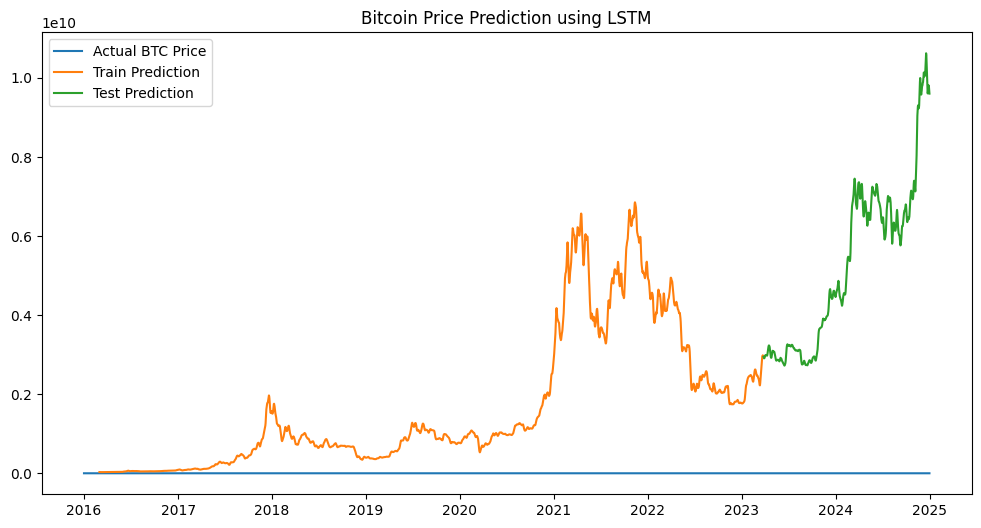

In [10]:
#Visualization

plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label="Actual BTC Price")

train_plot = np.empty_like(scaled_data)
train_plot[:] = np.nan
train_plot[time_step:train_size+time_step] = train_predict

test_plot = np.empty_like(scaled_data)
test_plot[:] = np.nan
test_plot[train_size+time_step:] = test_predict

plt.plot(data.index, scaler.inverse_transform(train_plot), label="Train Prediction")
plt.plot(data.index, scaler.inverse_transform(test_plot), label="Test Prediction")

plt.legend()
plt.title("Bitcoin Price Prediction using LSTM")
plt.show()


In [11]:
#Convert BTC data to MONTHLY

df = yf.download("BTC-USD", start="2016-01-01", end="2026-01-10")

monthly_close = df['Close'].resample('M').last()
monthly_close.dropna(inplace=True)

/tmp/ipython-input-4217088916.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2016-01-01", end="2026-01-10")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4217088916.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['Close'].resample('M').last()


In [12]:
#Compute MONTHLY Log Returns (KEY)

log_returns = np.log(monthly_close / monthly_close.shift(1))
log_returns.dropna(inplace=True)

In [13]:
#Scale Returns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_returns = scaler.fit_transform(log_returns.values.reshape(-1, 1))

In [14]:
#Create Sequences (6–12 months window)
def create_dataset(data, window=6):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window = 6
X, y = create_dataset(scaled_returns, window)
X = X.reshape(X.shape[0], X.shape[1], 1)


In [15]:
#Train / Test Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [16]:
#LSTM Model (Simple & Stable)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(window,1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=40, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.1706 - val_loss: 0.0556
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1760 - val_loss: 0.0591
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1695 - val_loss: 0.0604
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1817 - val_loss: 0.0605
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1812 - val_loss: 0.0592
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1911 - val_loss: 0.0601
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1718 - val_loss: 0.0609
Epoch 8/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1715 - val_loss: 0.0603
Epoch 9/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1951 - val_loss: 0.0627
Epoch 10/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1682 - val_loss: 0.0626
Epoch 11/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2013 - val_loss: 0.0627
Epoch 12/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1959 - val_l

In [17]:
#Predict JAN 2026 Monthly Return
last_window = scaled_returns[-window:].reshape(1, window, 1)

pred_return = model.predict(last_window, verbose=0)
pred_return = scaler.inverse_transform(pred_return)[0,0]

In [18]:
#Reconstruct BTC Price for Jan 2026
last_price = monthly_close.iloc[-1]

jan_2026_price = last_price * np.exp(pred_return)

print("Predicted BTC Price for Jan 2026:", jan_2026_price)

Predicted BTC Price for Jan 2026: Ticker
BTC-USD    92965.895728
Name: 2026-01-31 00:00:00, dtype: float64


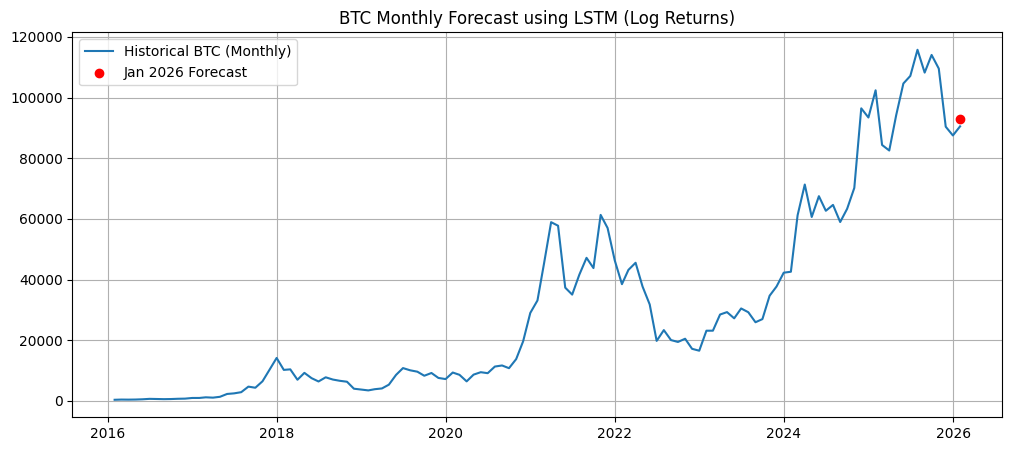

In [19]:
#Visual (Monthly – Correct Way)
plt.figure(figsize=(12,5))
plt.plot(monthly_close.index, monthly_close.values, label="Historical BTC (Monthly)")
plt.scatter(pd.Timestamp("2026-01-31"), jan_2026_price, color='red', label="Jan 2026 Forecast")
plt.legend()
plt.title("BTC Monthly Forecast using LSTM (Log Returns)")
plt.grid(True)
plt.show()